## Conversation Memory Buffer
##### 1. Basic Memory
##### 2. Ex Think of it as Take Recorder That never pauses
### How is it done:
###### 1. Keep an Ordereed List of Messages
###### 2. Send entire list to LLM on every turn.
###### 3. Append the response. Repeat.

In [2]:
#%pip install -q openai python-dotenv matplotlib langchain langchain-openai

In [5]:
#print(Path.cwd().resolve().parent)

In [10]:
import sys
from pathlib import Path

# If notebook is inside notebooks/memory-techniques/
project_root = Path.cwd().resolve().parents[1]

print(f"Adding project root to sys.path: {project_root}")
sys.path.insert(0, str(project_root))

from utils.env_loader import load_environment
_ = load_environment()

Adding project root to sys.path: /Users/kanderaolaxminarasimharao/Downloads/MyAgents-Git/MyAgents


In [11]:
from openai import OpenAI
import copy

class ConversationBufferMemory:
    """Minimal conversation buffer memory built on the OpenAI SDK."""

    def __init__(
        self,
        model: str = "gpt-4.1-mini",
        system_prompt: str | None = None,
        max_tokens: int = 1024,
    ):
        self.client = OpenAI()
        self.model = model
        self.system_prompt = system_prompt
        self.max_tokens = max_tokens

        # Core data structure: the message buffer
        self.messages: list[dict] = []

        # Bookkeeping for the token-growth demo
        self.turn_token_usage: list[dict] = []

    # ── Message helpers ──────────────────────────────────────────────
    def add_user_message(self, content: str) -> None:
        self.messages.append({"role": "user", "content": content})

    def add_assistant_message(self, content: str) -> None:
        self.messages.append({"role": "assistant", "content": content})

    # ── Chat ─────────────────────────────────────────────────────────
    def chat(self, user_input: str) -> str:
        """Send a message and get a response. The *entire* buffer is sent."""
        self.add_user_message(user_input)

        kwargs = dict(
            model=self.model,
            input=self.messages,   # <-- full history every time
            max_output_tokens=self.max_tokens,
        )
        if self.system_prompt:
            kwargs["instructions"] = self.system_prompt

        response = self.client.responses.create(**kwargs)

        assistant_text = response.output_text
        self.add_assistant_message(assistant_text)

        # Record token usage for this turn
        self.turn_token_usage.append({
            "turn": len(self.turn_token_usage) + 1,
            "input_tokens": response.usage.input_tokens if response.usage else None,
            "output_tokens": response.usage.output_tokens if response.usage else None,
        })

        return assistant_text

    # ── Utilities ────────────────────────────────────────────────────
    def get_history(self) -> list[dict]:
        return copy.deepcopy(self.messages)

    def clear(self) -> None:
        self.messages.clear()
        self.turn_token_usage.clear()

    def __len__(self) -> int:
        return len(self.messages)

    def __repr__(self) -> str:
        return f"ConversationBufferMemory({len(self.messages)} messages)"

In [12]:
memory = ConversationBufferMemory(
    system_prompt="You are a helpful, concise assistant. Keep replies under 2 sentences.",
)

# Multi-turn conversation
exchanges = [
    "Hi! My name is Alice and I'm a machine-learning engineer.",
    "I'm working on a project about agent memory. Any tips?",
    "What's my name and what do I do?",  # recall test
]

for msg in exchanges:
    print(f"👤 User:  {msg}")
    reply = memory.chat(msg)
    print(f"🤖 Agent: {reply}\n")

print(f"Buffer now contains {len(memory)} messages.")

👤 User:  Hi! My name is Alice and I'm a machine-learning engineer.
🤖 Agent: Hi Alice! Great to meet a machine-learning engineer—how can I assist you today?

👤 User:  I'm working on a project about agent memory. Any tips?
🤖 Agent: Focus on balancing short-term and long-term memory mechanisms, like using attention models for recent context and external memory modules for longer retention. Also, ensure efficient memory retrieval to maintain performance.

👤 User:  What's my name and what do I do?
🤖 Agent: Your name is Alice, and you’re a machine-learning engineer.

Buffer now contains 6 messages.


In [13]:
print(f"Buffer now contains {len(memory)} messages.")

for turn in memory.turn_token_usage:
    print(
        f"Turn {turn['turn']}: "
        f"input tokens = {turn['input_tokens']}, "
        f"output tokens = {turn['output_tokens']}"
    )

Buffer now contains 6 messages.
Turn 1: input tokens = 39, output tokens = 19
Turn 2: input tokens = 77, output tokens = 37
Turn 3: input tokens = 130, output tokens = 14


In [14]:

# Peek at the raw message buffer
for i, msg in enumerate(memory.get_history()):
    role_label = "USER" if msg["role"] == "user" else "ASST"
    # Truncate long messages for display
    preview = msg["content"][:80] + ("..." if len(msg["content"]) > 80 else "")
    print(f"  [{i}] {role_label}: {preview}")

  [0] USER: Hi! My name is Alice and I'm a machine-learning engineer.
  [1] ASST: Hi Alice! Great to meet a machine-learning engineer—how can I assist you today?
  [2] USER: I'm working on a project about agent memory. Any tips?
  [3] ASST: Focus on balancing short-term and long-term memory mechanisms, like using attent...
  [4] USER: What's my name and what do I do?
  [5] ASST: Your name is Alice, and you’re a machine-learning engineer.


In [17]:
print(memory.system_prompt)
#print(memory.get_system_prompt())

You are a helpful, concise assistant. Keep replies under 2 sentences.


In [18]:
# Run a longer conversation to see the growth curve
memory_demo = ConversationBufferMemory(
    system_prompt="You are a helpful assistant. Keep answers to 1-2 sentences.",
)

demo_messages = [
    "Hello! I'm Bob.",
    "I live in San Francisco.",
    "I have a golden retriever named Max.",
    "My favorite programming language is Python.",
    "I work at a startup that builds AI tools.",
    "We're building a chatbot with memory capabilities.",
    "Our team has 12 engineers.",
    "We use Claude as our primary LLM.",
    "What do you know about me so far?",
    "Summarize everything you remember about me in a list.",
]

for msg in demo_messages:
    reply = memory_demo.chat(msg)

print(f"Completed {len(memory_demo.turn_token_usage)} turns.")
print("\nToken usage per turn:")
for t in memory_demo.turn_token_usage:
    print(f"  Turn {t['turn']:2d}: {t['input_tokens']:5d} input tokens, {t['output_tokens']:4d} output tokens")

Completed 10 turns.

Token usage per turn:
  Turn  1:    31 input tokens,   12 output tokens
  Turn  2:    56 input tokens,   20 output tokens
  Turn  3:    92 input tokens,   17 output tokens
  Turn  4:   123 input tokens,   17 output tokens
  Turn  5:   157 input tokens,   22 output tokens
  Turn  6:   194 input tokens,   21 output tokens
  Turn  7:   229 input tokens,   25 output tokens
  Turn  8:   270 input tokens,   22 output tokens
  Turn  9:   308 input tokens,   54 output tokens
  Turn 10:   381 input tokens,   65 output tokens


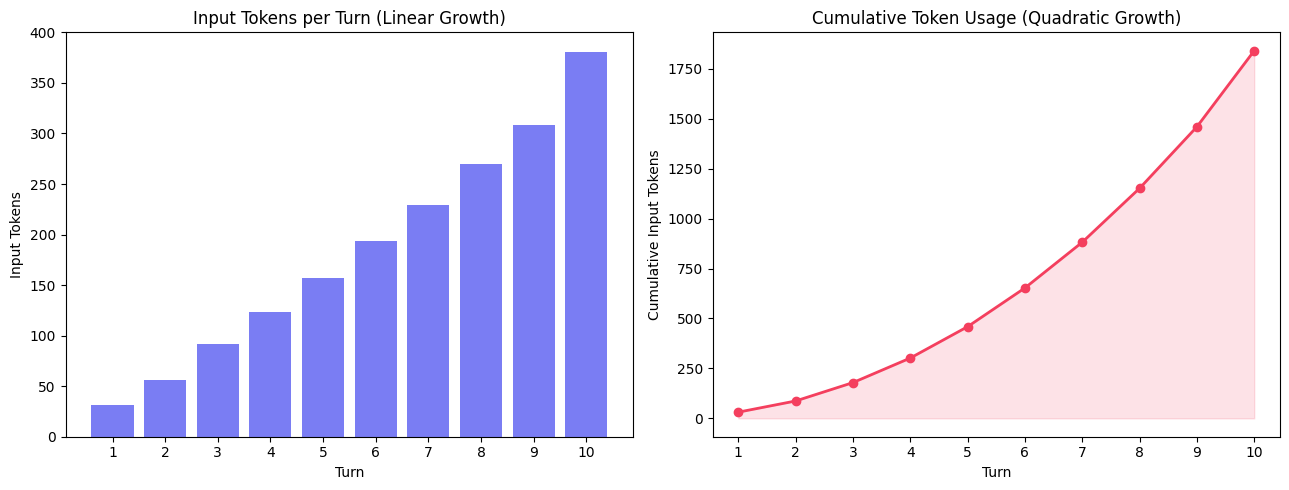


Total input tokens across all turns: 1,841
If using a window/summary approach, this could be drastically reduced.


In [19]:
import matplotlib.pyplot as plt
import numpy as np

turns = [t["turn"] for t in memory_demo.turn_token_usage]
input_tokens = [t["input_tokens"] for t in memory_demo.turn_token_usage]
cumulative = np.cumsum(input_tokens)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: input tokens per turn (linear growth)
ax1.bar(turns, input_tokens, color="#6366f1", alpha=0.85)
ax1.set_xlabel("Turn")
ax1.set_ylabel("Input Tokens")
ax1.set_title("Input Tokens per Turn (Linear Growth)")
ax1.set_xticks(turns)

# Right: cumulative input tokens (quadratic growth)
ax2.plot(turns, cumulative, "o-", color="#f43f5e", linewidth=2, markersize=6)
ax2.fill_between(turns, cumulative, alpha=0.15, color="#f43f5e")
ax2.set_xlabel("Turn")
ax2.set_ylabel("Cumulative Input Tokens")
ax2.set_title("Cumulative Token Usage (Quadratic Growth)")
ax2.set_xticks(turns)

plt.tight_layout()
plt.savefig("token_growth.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal input tokens across all turns: {int(cumulative[-1]):,}")
print(f"If using a window/summary approach, this could be drastically reduced.")

In [21]:
import json
def save_conversation(memory: ConversationBufferMemory, path: str) -> None:
    """Persist the message buffer to a JSON file."""
    with open(path, "w") as f:
        json.dump(memory.get_history(), f, indent=2)
    print(f"Saved {len(memory)} messages → {path}")


def load_conversation(path: str, **kwargs) -> ConversationBufferMemory:
    """Restore a ConversationBufferMemory from a JSON file."""
    with open(path) as f:
        messages = json.load(f)
    mem = ConversationBufferMemory(**kwargs)
    mem.messages = messages
    print(f"Loaded {len(messages)} messages ← {path}")
    return mem


# Demo round-trip
save_conversation(memory, "conversation.json")
loaded = load_conversation(
    "conversation.json",
    system_prompt="You are a helpful, concise assistant. Keep replies under 2 sentences.",
)

# Verify the loaded memory still works
reply = loaded.chat("Remind me - what project was I working on?")
print(f"\n🤖 Agent (from loaded memory): {reply}")

Saved 6 messages → conversation.json
Loaded 6 messages ← conversation.json

🤖 Agent (from loaded memory): You’re working on a project about agent memory.


### Do the same with LangChain

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferMemory

llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
)

memory = ConversationBufferMemory()

conversation = ConversationChain(
    llm=llm,
    memory=memory,
    verbose=True,
)

conversation.invoke("Hi, my name is Suman.")
conversation.invoke("I am learning conversation buffer memory.")
response = conversation.invoke("What is my name and what am I learning?")

print(response["response"])

In [ ]:
from langchain_anthropic import ChatAnthropic
from langchain.memory import ConversationBufferMemory as LCBufferMemory
from langchain.chains import ConversationChain

llm = ChatAnthropic(model="claude-sonnet-4-20250514", max_tokens=1024)

lc_memory = LCBufferMemory(return_messages=True)

chain = ConversationChain(
    llm=llm,
    memory=lc_memory,
    verbose=False,
)

# Same conversation
print("👤:", "Hi, my name is Charlie.")
print("🤖:", chain.predict(input="Hi, my name is Charlie."), "\n")

print("👤:", "I'm building a knowledge graph for my company.")
print("🤖:", chain.predict(input="I'm building a knowledge graph for my company."), "\n")

print("👤:", "What's my name and what am I building?")
print("🤖:", chain.predict(input="What's my name and what am I building?"), "\n")

# Inspect LangChain's internal buffer
print("--- LangChain buffer contents ---")
for msg in lc_memory.chat_memory.messages:
    role = msg.__class__.__name__.replace("Message", "")
    preview = msg.content[:80] + ("..." if len(msg.content) > 80 else "")
    print(f"  {role}: {preview}")